In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2_contingency, fisher_exact
import matplotlib.font_manager as fm

In [4]:
!apt-get install -y fonts-nanum -q > /dev/null


fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

In [5]:
df=pd.read_csv('/content/FDA_adverse_events_final.csv')

In [6]:
def U(s): return '' if pd.isna(s) else str(s).upper()

def classify_b(row):
    sd = U(row['suspect_drug']); bn = U(row['brand_name']); t = sd + ' ' + bn
    if 'FOLIC ACID' in t or 'FOLATE' in t:
        return 'A. 엽산제(Folic Acid)'
    if 'FERROUS' in t or ('IRON' in t and 'GOLD' not in t) or 'AMYLOFER' in t:
        return 'B. 철분제'
    return 'C. 복합미네랄제'

B = df[df['WHO_ATC']=='B'].copy()
B['category'] = B.apply(classify_b, axis=1)

print(B['category'].value_counts())
print((B['category'].value_counts() / len(B) * 100).round(1))

F = B[B['category']=='A. 엽산제(Folic Acid)'].copy()
print(f"\n엽산제 그룹: {len(F)}건")

category
A. 엽산제(Folic Acid)    69
B. 철분제                24
C. 복합미네랄제              1
Name: count, dtype: int64
category
A. 엽산제(Folic Acid)    73.4
B. 철분제                25.5
C. 복합미네랄제              1.1
Name: count, dtype: float64

엽산제 그룹: 69건


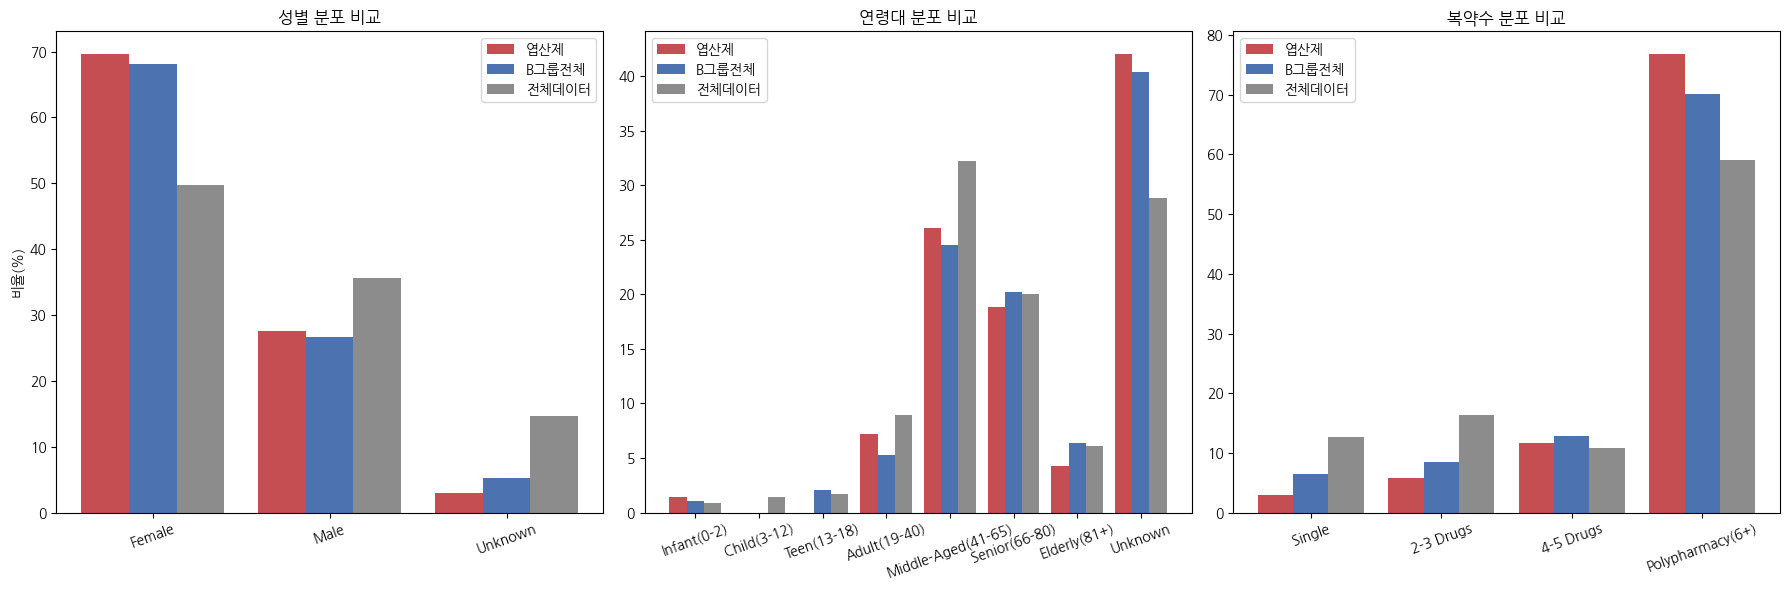

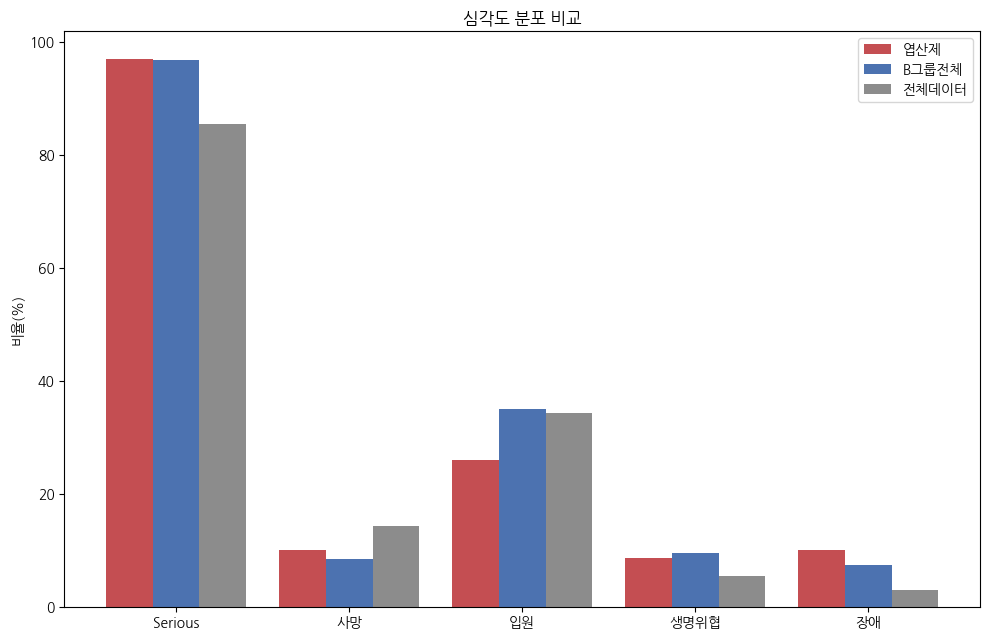

In [7]:

def dist_table(d, col, label):
    cnt = d[col].value_counts()
    pct = (cnt / len(d) * 100).round(1)
    return pd.DataFrame({f'{label}_건수': cnt, f'{label}_비율(%)': pct})

sex_f = dist_table(F, 'patient_sex', '엽산제')
sex_b = dist_table(B, 'patient_sex', 'B그룹전체')
sex_all = dist_table(df, 'patient_sex', '전체데이터')
sex_compare = sex_f.join(sex_b, how='outer').join(sex_all, how='outer').fillna(0)

age_order = ['Infant(0-2)','Child(3-12)','Teen(13-18)','Adult(19-40)',
             'Middle-Aged(41-65)','Senior(66-80)','Elderly(81+)','Unknown']  # 전체 연령대로 복원

age_f = dist_table(F, 'age_group', '엽산제')
age_b = dist_table(B, 'age_group', 'B그룹전체')
age_all = dist_table(df, 'age_group', '전체데이터')
age_compare = age_f.join(age_b, how='outer').join(age_all, how='outer').fillna(0)
age_compare = age_compare.reindex(age_order).fillna(0)

dc_order = ['Single','2-3 Drugs','4-5 Drugs','Polypharmacy(6+)']
dc_f = dist_table(F, 'drug_count_category', '엽산제')
dc_b = dist_table(B, 'drug_count_category', 'B그룹전체')
dc_all = dist_table(df, 'drug_count_category', '전체데이터')
dc_compare = dc_f.join(dc_b, how='outer').join(dc_all, how='outer').fillna(0).reindex(dc_order).fillna(0)

sev_cols = ['serious','is_fatal','is_hospitalized','is_life_threat','is_disabling']
def sev_rate(d, col):
    v = d[col].astype(str)
    pos = 'Yes' if col == 'serious' else 'True'
    return round((v == pos).mean() * 100, 1)

plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
w = 0.27

def plot3(ax, compare_df, title):
    x = range(len(compare_df))
    ax.bar([i-w for i in x], compare_df['엽산제_비율(%)'], width=w, label='엽산제', color='#C44E52')
    ax.bar([i for i in x], compare_df['B그룹전체_비율(%)'], width=w, label='B그룹전체', color='#4C72B0')
    ax.bar([i+w for i in x], compare_df['전체데이터_비율(%)'], width=w, label='전체데이터', color='#8C8C8C')
    ax.set_xticks(x); ax.set_xticklabels(compare_df.index, rotation=20)
    ax.set_title(title)
    ax.legend()

plot3(axes[0], sex_compare, '성별 분포 비교')
axes[0].set_ylabel('비율(%)')
plot3(axes[1], age_compare, '연령대 분포 비교')
plot3(axes[2], dc_compare, '복약수 분포 비교')
plt.tight_layout()
plt.show()

fig2, ax = plt.subplots(figsize=(10, 6.5))
sev_labels = ['Serious','사망','입원','생명위협','장애']
f_rates = [sev_rate(F,c) for c in sev_cols]
b_rates = [sev_rate(B,c) for c in sev_cols]
a_rates = [sev_rate(df,c) for c in sev_cols]
x = range(len(sev_labels))
ax.bar([i-w for i in x], f_rates, width=w, label='엽산제', color='#C44E52')
ax.bar([i for i in x], b_rates, width=w, label='B그룹전체', color='#4C72B0')
ax.bar([i+w for i in x], a_rates, width=w, label='전체데이터', color='#8C8C8C')
ax.set_xticks(x); ax.set_xticklabels(sev_labels)
ax.set_ylabel('비율(%)')
ax.set_title('심각도 분포 비교')
ax.legend()
plt.tight_layout()
plt.show()

reaction_cat
기타                    12
류마티스/자가면역(기저질환 추정)     9
전신/장기손상(심각)            8
신경계/의식(심각)             8
소화기/미각                 8
피부관련                   8
치료효과 관련                7
임신 관련                  6
오남용/사용행태               3
Name: count, dtype: int64


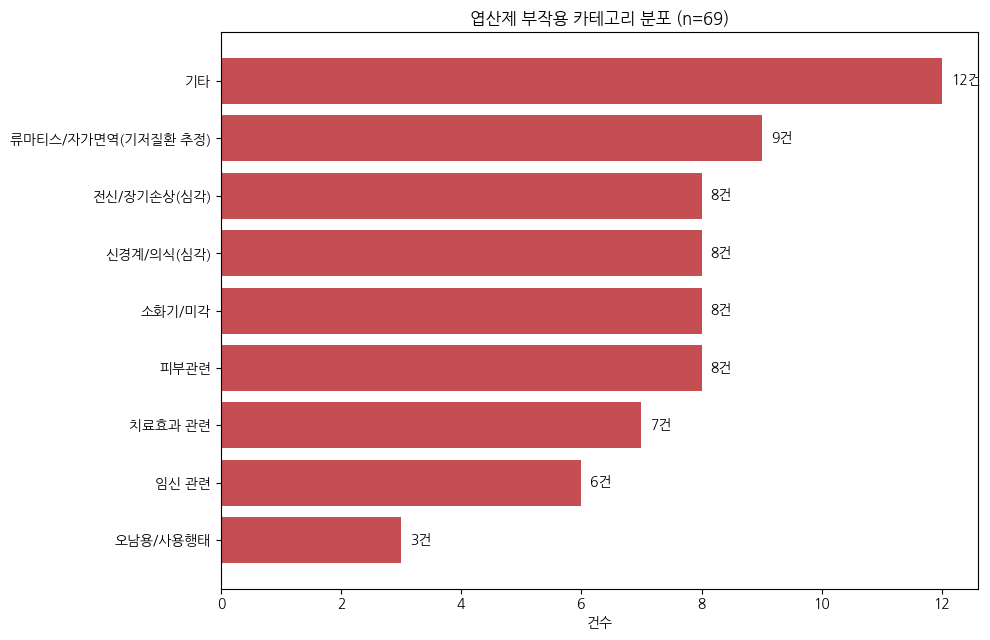

In [8]:
def reaction_category(reaction):
    t = str(reaction).upper()
    autoimmune_kw = ['RHEUMATOID','ARTHRALGIA','ARTHRODESIS','ARTHROPATHY','LUPUS','PSORIATIC','NEUROGENIC BLADDER']
    systemic_kw = ['KOUNIS','RENAL FAILURE','BONE MARROW','RESPIRATORY DISTRESS','PNEUMONIA','HAEMORRHAGE','CHOLESTASIS','CHEST PAIN']
    neuro_kw = ['LOSS OF CONSCIOUSNESS','CONFUSIONAL','MIOSIS','BLINDNESS','SEIZURE','CEREBROVASCULAR','AUTOSCOPY','NEUROPATHY']
    skin_kw = ['ALOPECIA','PEMPHIGUS','BLISTER','CELLULITIS','INFECTED SKIN ULCER','ANGIOEDEMA']
    gi_kw = ['ABDOMINAL','GLOSSODYNIA','VOMITING','DIVERTICULITIS']
    effect_kw = ['INEFFECTIVE','THERAPEUTIC PRODUCT EFFECT','DISEASE PROGRESSION','IRON DEFICIENCY']
    preg_kw = ['PREGNANCY','PREMATURE DELIVERY','ANENCEPHALY']
    misuse_kw = ['MISUSE','CONTRAINDICATED','INJECTION SITE']

    if any(k in t for k in autoimmune_kw): return '류마티스/자가면역(기저질환 추정)'
    if any(k in t for k in systemic_kw): return '전신/장기손상(심각)'
    if any(k in t for k in neuro_kw): return '신경계/의식(심각)'
    if any(k in t for k in skin_kw): return '피부관련'
    if any(k in t for k in gi_kw): return '소화기/미각'
    if any(k in t for k in effect_kw): return '치료효과 관련'
    if any(k in t for k in preg_kw): return '임신 관련'
    if any(k in t for k in misuse_kw): return '오남용/사용행태'
    return '기타'

F['reaction_cat'] = F['primary_reaction'].apply(reaction_category)
print(F['reaction_cat'].value_counts())

plt.rcParams['axes.unicode_minus'] = False

cat_counts = F['reaction_cat'].value_counts()
fig, ax = plt.subplots(figsize=(10, 6.5))
bars = ax.barh(cat_counts.index[::-1], cat_counts.values[::-1], color='#C44E52')
for bar, c in zip(bars, cat_counts.values[::-1]):
    ax.text(bar.get_width()+0.15, bar.get_y()+bar.get_height()/2, f'{c}건', va='center', fontsize=10)
ax.set_xlabel('건수')
ax.set_title(f'엽산제 부작용 카테고리 분포 (n={len(F)})')
plt.tight_layout()
plt.show()

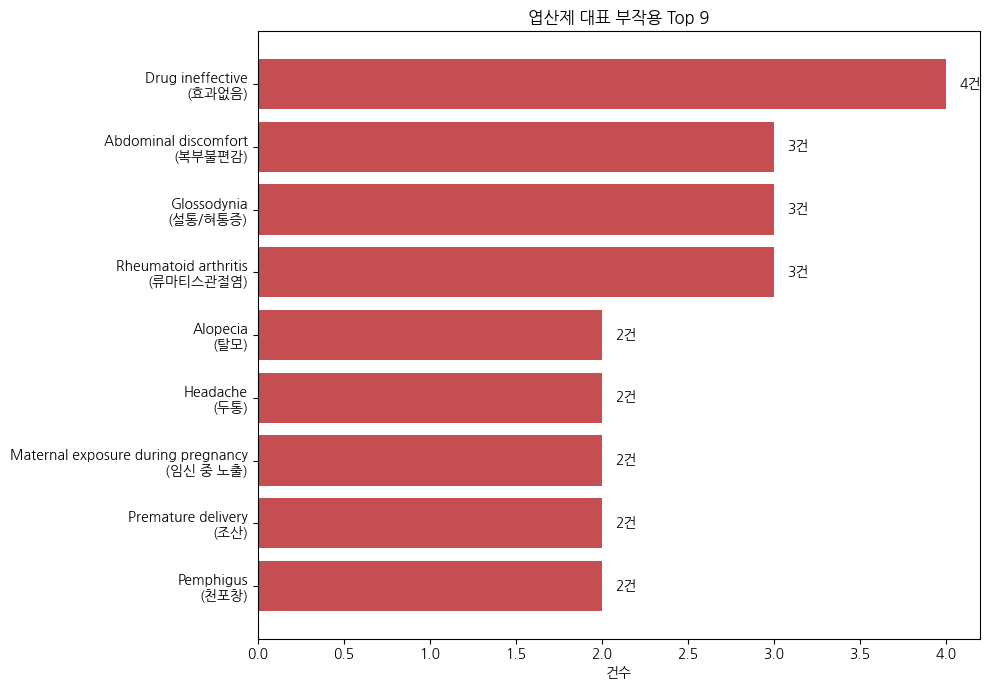

In [9]:

translation = {
    'Drug ineffective': '효과없음',
    'Abdominal discomfort': '복부불편감',
    'Glossodynia': '설통/혀통증',
    'Rheumatoid arthritis': '류마티스관절염',
    'Alopecia': '탈모',
    'Maternal exposure during pregnancy': '임신 중 노출',
    'Headache': '두통',
    'Premature delivery': '조산',
    'Pemphigus': '천포창',
}

top_reactions = F['primary_reaction'].value_counts()
top_reactions_multi = top_reactions[top_reactions >= 2]

labels = [f'{name}\n({translation.get(name, "")})' for name in top_reactions_multi.index]

plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(labels[::-1], top_reactions_multi.values[::-1], color='#C44E52')
for bar, c in zip(bars, top_reactions_multi.values[::-1]):
    ax.text(bar.get_width()+0.08, bar.get_y()+bar.get_height()/2, f'{c}건', va='center', fontsize=10)
ax.set_xlabel('건수')
ax.set_title(f'엽산제 대표 부작용 Top {len(top_reactions_multi)}')
plt.tight_layout()
plt.show()

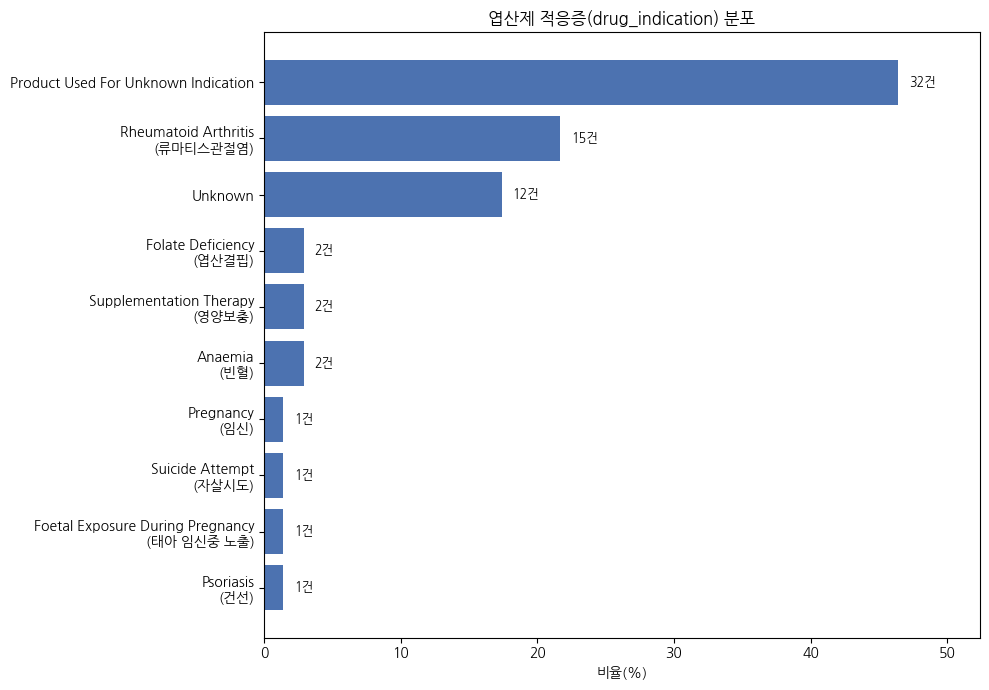

In [10]:
plt.rcParams['axes.unicode_minus'] = False

translation = {
    'Product Used For Unknown Indication': '',
    'Rheumatoid Arthritis': '류마티스관절염',
    'Unknown': '',
    'Supplementation Therapy': '영양보충',
    'Folate Deficiency': '엽산결핍',
    'Anaemia': '빈혈',
    'Pregnancy': '임신',
    'Suicide Attempt': '자살시도',
    'Psoriasis': '건선',
    'Foetal Exposure During Pregnancy': '태아 임신중 노출',
}

ind = F['drug_indication'].value_counts()
pct = (ind / len(F) * 100).round(1)

labels = []
for name in ind.index:
    kr = translation.get(name, '')
    labels.append(f'{name}\n({kr})' if kr else name)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(labels[::-1], pct[::-1], color='#4C72B0')
for bar, c in zip(bars, ind.values[::-1]):
    ax.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height()/2, f'{c}건', va='center', fontsize=9)
ax.set_xlabel('비율(%)')
ax.set_xlim(0, max(pct) + 6)
ax.set_title(f'엽산제 적응증(drug_indication) 분포')
plt.tight_layout()
plt.show()

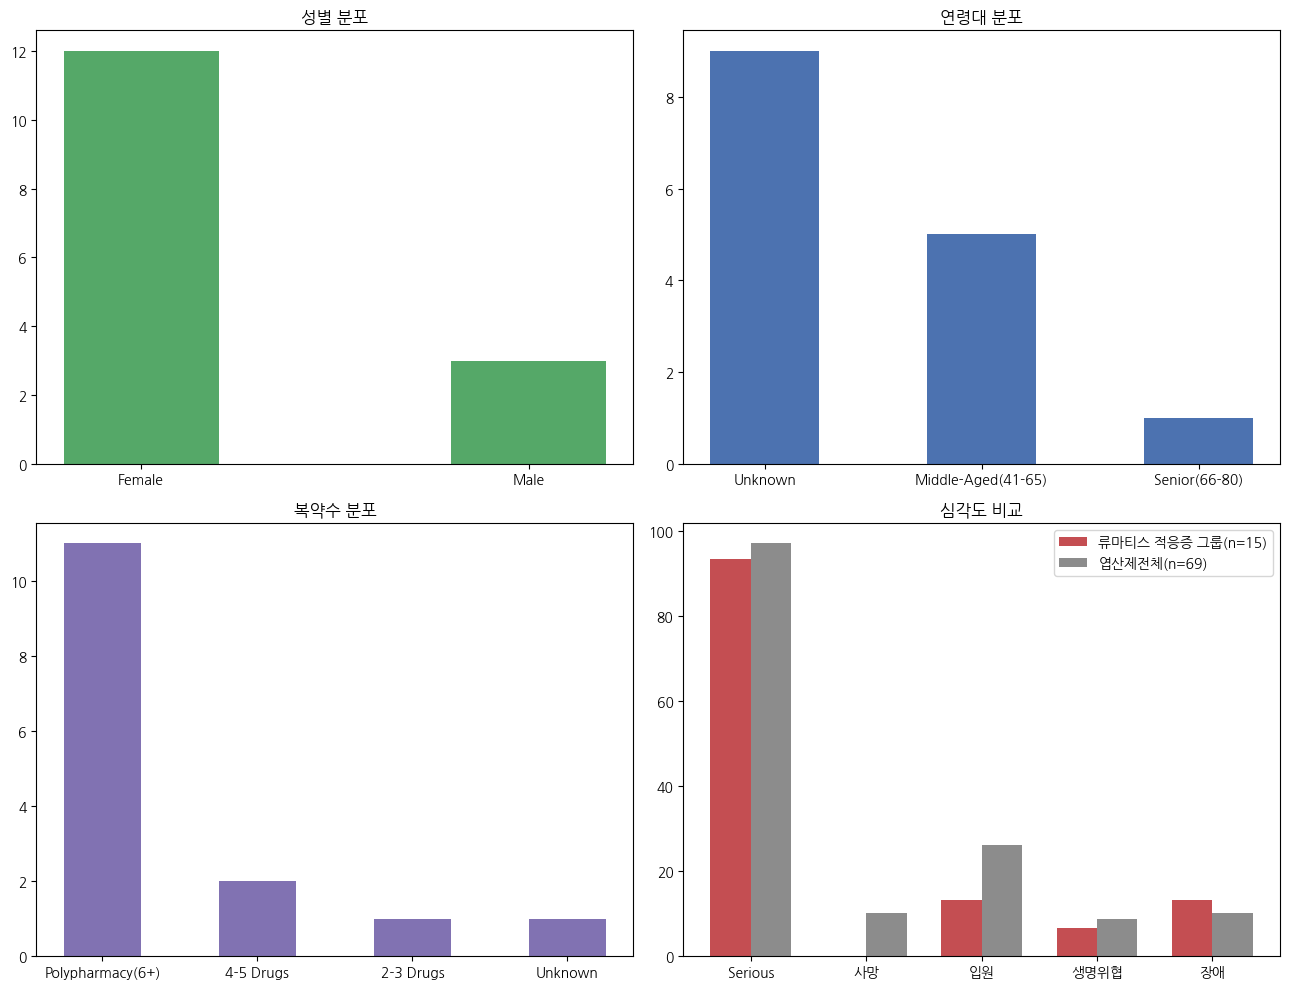

In [11]:
RA = F[F['drug_indication']=='Rheumatoid Arthritis'].copy()

for col in ['serious','is_fatal','is_hospitalized','is_life_threat','is_disabling']:
    v = RA[col].astype(str)
    pos = 'Yes' if col=='serious' else 'True'

plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

sex_counts = RA['patient_sex'].value_counts()
axes[0,0].bar(sex_counts.index, sex_counts.values, color='#55A868', width=0.4)
axes[0,0].set_title(f'성별 분포')

age_counts = RA['age_group'].value_counts()
axes[0,1].bar(age_counts.index, age_counts.values, color='#4C72B0', width=0.5)
axes[0,1].set_title('연령대 분포')

dc_counts = RA['drug_count_category'].value_counts()
axes[1,0].bar(dc_counts.index, dc_counts.values, color='#8172B2', width=0.5)
axes[1,0].set_title(f'복약수 분포')

sev_cols = ['serious','is_fatal','is_hospitalized','is_life_threat','is_disabling']
sev_labels = ['Serious','사망','입원','생명위협','장애']
ra_sev = [(RA[c].astype(str)==('Yes' if c=='serious' else 'True')).mean()*100 for c in sev_cols]
f_sev = [(F[c].astype(str)==('Yes' if c=='serious' else 'True')).mean()*100 for c in sev_cols]
x = range(len(sev_labels)); w = 0.35
axes[1,1].bar([i-w/2 for i in x], ra_sev, width=w, label=f'류마티스 적응증 그룹(n={len(RA)})', color='#C44E52')
axes[1,1].bar([i+w/2 for i in x], f_sev, width=w, label=f'엽산제전체(n={len(F)})', color='#8C8C8C')
axes[1,1].set_xticks(x); axes[1,1].set_xticklabels(sev_labels)
axes[1,1].legend()
axes[1,1].set_title('심각도 비교')

plt.tight_layout()
plt.show()

전체 9개 반응 Chi-square: p=0.4899 (기대빈도 대부분 5 미만이라 신뢰도 낮음)
관련군(n=7) vs 무관군(n=10): Fisher's exact p=0.0147


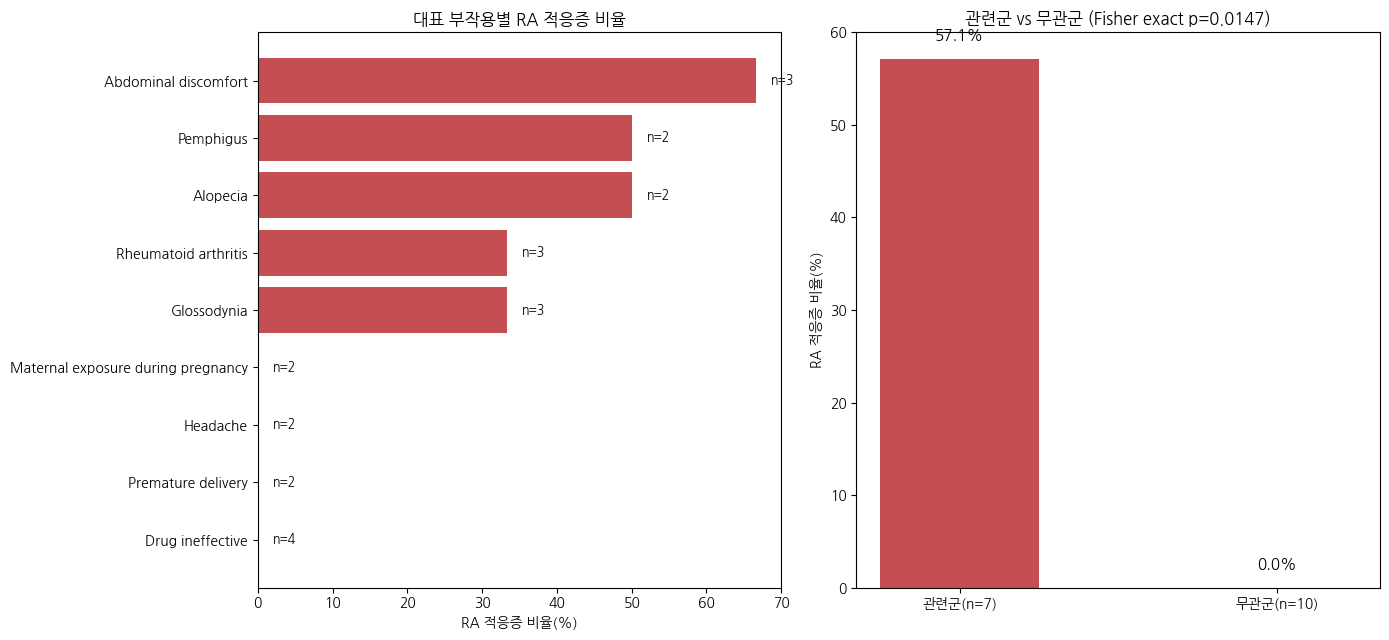

In [12]:

top9 = ['Drug ineffective','Abdominal discomfort','Glossodynia','Rheumatoid arthritis',
        'Alopecia','Maternal exposure during pregnancy','Headache','Premature delivery','Pemphigus']

sub = F[F['primary_reaction'].isin(top9)].copy()
sub['is_RA'] = sub['drug_indication'] == 'Rheumatoid Arthritis'

# 1. 전체 9개 반응 x RA여부
tab = pd.crosstab(sub['primary_reaction'], sub['is_RA']).reindex(top9)
chi2, p, dof, exp = chi2_contingency(tab)
print(f"전체 9개 반응 Chi-square: p={p:.4f} (기대빈도 대부분 5 미만이라 신뢰도 낮음)")

# 2. 관련군 vs 무관군 그룹 검정
related = sub[sub['primary_reaction'].isin(['Abdominal discomfort','Pemphigus','Alopecia'])]
unrelated = sub[sub['primary_reaction'].isin(['Drug ineffective','Headache','Maternal exposure during pregnancy','Premature delivery'])]

tab2 = [[related['is_RA'].sum(), (~related['is_RA']).sum()],
        [unrelated['is_RA'].sum(), (~unrelated['is_RA']).sum()]]
odds, p2 = fisher_exact(tab2)
print(f"관련군(n={len(related)}) vs 무관군(n={len(unrelated)}): Fisher's exact p={p2:.4f}")

# 3. 시각화
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))

reaction_ra_pct = sub.groupby('primary_reaction')['is_RA'].mean().reindex(top9) * 100
reaction_n = sub.groupby('primary_reaction').size().reindex(top9)
colors = ['#C44E52' if p > 0 else '#8C8C8C' for p in reaction_ra_pct]

order = reaction_ra_pct.sort_values().index
bars = axes[0].barh(order, reaction_ra_pct.reindex(order), color=[colors[top9.index(r)] for r in order])
for bar, n in zip(bars, reaction_n.reindex(order)):
    axes[0].text(bar.get_width()+2, bar.get_y()+bar.get_height()/2, f'n={n}', va='center', fontsize=9)
axes[0].set_xlabel('RA 적응증 비율(%)')
axes[0].set_title('대표 부작용별 RA 적응증 비율')

group_pct = [related['is_RA'].mean()*100, unrelated['is_RA'].mean()*100]
bars2 = axes[1].bar([f'관련군(n={len(related)})', f'무관군(n={len(unrelated)})'], group_pct, color=['#C44E52','#8C8C8C'], width=0.5)
for bar, v in zip(bars2, group_pct):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+2, f'{v:.1f}%', ha='center', fontsize=11)
axes[1].set_ylabel('RA 적응증 비율(%)')
axes[1].set_title(f'관련군 vs 무관군 (Fisher exact p={p2:.4f})')

plt.tight_layout()
plt.show()

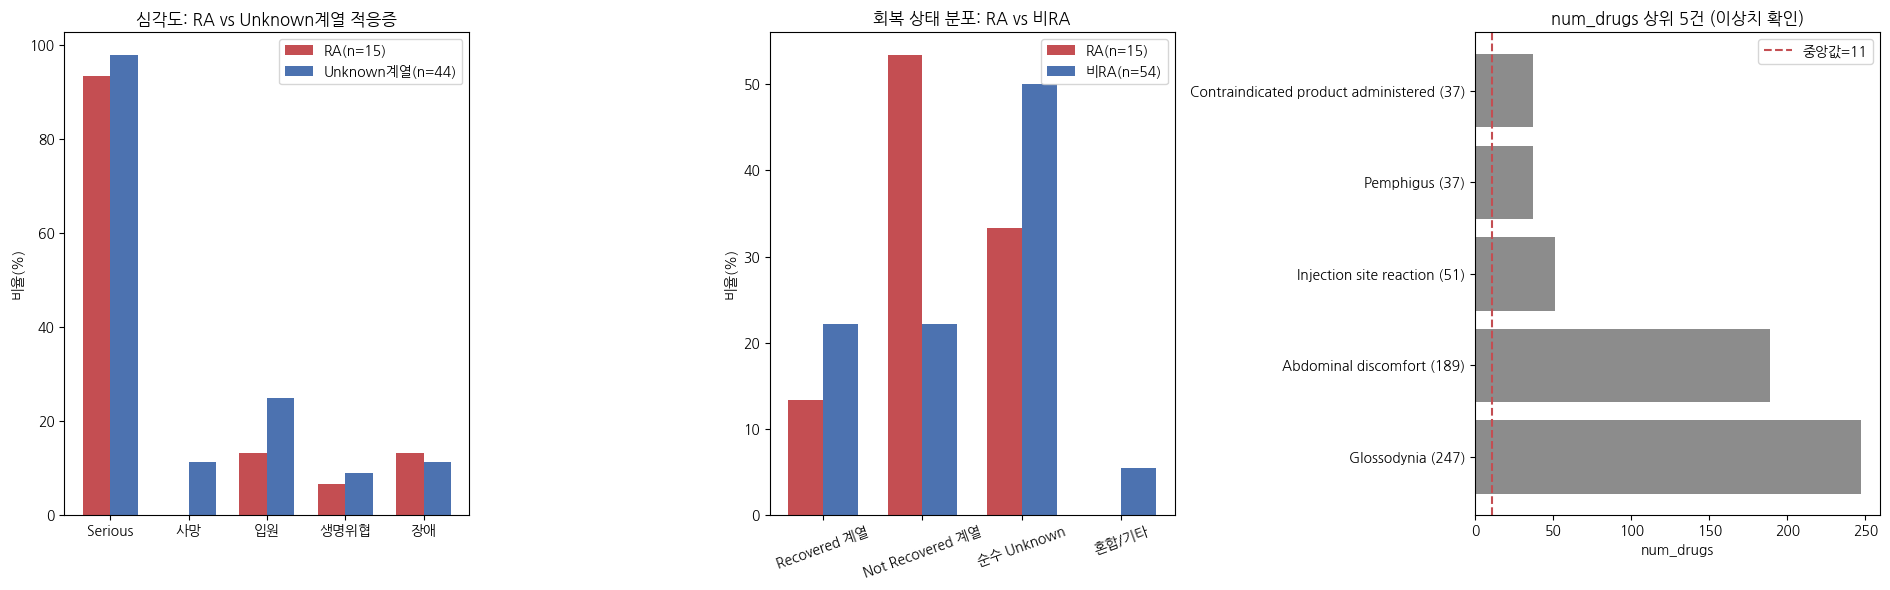

In [13]:

fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')  # 로컬이면 생략 가능
plt.rcParams['axes.unicode_minus'] = False

# 0. 기본 세팅 (엽산제 그룹 F 재생성)
def U(s): return '' if pd.isna(s) else str(s).upper()

def classify_b(row):
    sd = U(row['suspect_drug']); bn = U(row['brand_name']); t = sd + ' ' + bn
    if 'FOLIC ACID' in t or 'FOLATE' in t: return 'A. 엽산제(Folic Acid)'
    if 'FERROUS' in t or ('IRON' in t and 'GOLD' not in t) or 'AMYLOFER' in t: return 'B. 철분제'
    return 'C. 복합미네랄제'

B = df[df['WHO_ATC']=='B'].copy()
B['category'] = B.apply(classify_b, axis=1)
F = B[B['category']=='A. 엽산제(Folic Acid)'].copy()

RA = F[F['drug_indication']=='Rheumatoid Arthritis'].copy()
nonRA = F[F['drug_indication']!='Rheumatoid Arthritis'].copy()
unknown_group = F[F['drug_indication'].isin(['Product Used For Unknown Indication','Unknown'])].copy()

# ===== 1. Unknown계열 그룹 vs RA그룹 심각도 비교 =====
def sev_rate(d, col):
    v = d[col].astype(str)
    pos = 'Yes' if col == 'serious' else 'True'
    return round((v == pos).mean() * 100, 1)

sev_cols = ['serious','is_fatal','is_hospitalized','is_life_threat','is_disabling']
sev_labels = ['Serious','사망','입원','생명위협','장애']
ra_sev = [sev_rate(RA, c) for c in sev_cols]
unk_sev = [sev_rate(unknown_group, c) for c in sev_cols]

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
w = 0.35
x = range(len(sev_labels))
axes[0].bar([i-w/2 for i in x], ra_sev, width=w, label=f'RA(n={len(RA)})', color='#C44E52')
axes[0].bar([i+w/2 for i in x], unk_sev, width=w, label=f'Unknown계열(n={len(unknown_group)})', color='#4C72B0')
axes[0].set_xticks(x); axes[0].set_xticklabels(sev_labels)
axes[0].set_ylabel('비율(%)')
axes[0].set_title('심각도: RA vs Unknown계열 적응증')
axes[0].legend()

# ===== 2. 회복 상태(reaction_outcomes) 분포 비교 =====
def outcome_group(o):
    o = str(o)
    if 'Not Recovered' in o and 'Recovered' not in o.replace('Not Recovered',''):
        return 'Not Recovered 계열'
    if 'Recovered' in o and 'Not Recovered' not in o:
        return 'Recovered 계열'
    if o == 'Unknown':
        return '순수 Unknown'
    return '혼합/기타'

RA['outcome_group'] = RA['reaction_outcomes'].apply(outcome_group)
nonRA['outcome_group'] = nonRA['reaction_outcomes'].apply(outcome_group)

outcome_order = ['Recovered 계열','Not Recovered 계열','순수 Unknown','혼합/기타']
ra_outcome_pct = RA['outcome_group'].value_counts(normalize=True).reindex(outcome_order).fillna(0) * 100
non_outcome_pct = nonRA['outcome_group'].value_counts(normalize=True).reindex(outcome_order).fillna(0) * 100

x2 = range(len(outcome_order))
axes[1].bar([i-w/2 for i in x2], ra_outcome_pct, width=w, label=f'RA(n={len(RA)})', color='#C44E52')
axes[1].bar([i+w/2 for i in x2], non_outcome_pct, width=w, label=f'비RA(n={len(nonRA)})', color='#4C72B0')
axes[1].set_xticks(x2); axes[1].set_xticklabels(outcome_order, rotation=20)
axes[1].set_ylabel('비율(%)')
axes[1].set_title('회복 상태 분포: RA vs 비RA')
axes[1].legend()

# ===== 3. num_drugs 상위 케이스 (이상치 포함) =====
top5 = F.nlargest(5, 'num_drugs')[['primary_reaction','num_drugs']]
axes[2].barh(top5['primary_reaction'] + ' (' + top5['num_drugs'].astype(str) + ')', top5['num_drugs'], color='#8C8C8C')
axes[2].axvline(F['num_drugs'].median(), color='#C44E52', linestyle='--', label=f'중앙값={F["num_drugs"].median():.0f}')
axes[2].set_xlabel('num_drugs')
axes[2].set_title('num_drugs 상위 5건 (이상치 확인)')
axes[2].legend()

plt.tight_layout()
plt.show()

단순 보충 목적: n=6
나머지: n=63


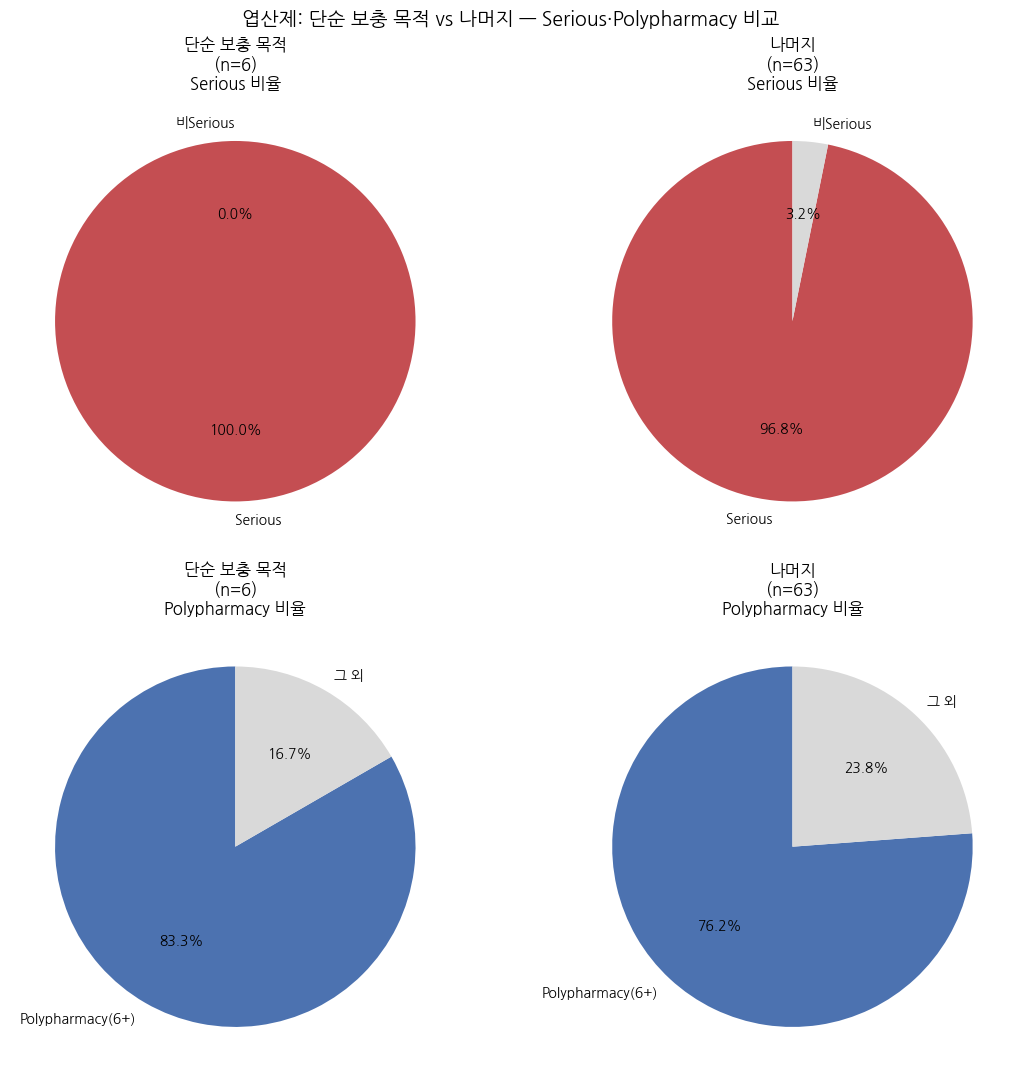

In [14]:
# 0. 엽산제 그룹(F) 재생성
def U(s): return '' if pd.isna(s) else str(s).upper()

def classify_b(row):
    sd = U(row['suspect_drug']); bn = U(row['brand_name']); t = sd + ' ' + bn
    if 'FOLIC ACID' in t or 'FOLATE' in t: return 'A. 엽산제(Folic Acid)'
    if 'FERROUS' in t or ('IRON' in t and 'GOLD' not in t) or 'AMYLOFER' in t: return 'B. 철분제'
    return 'C. 복합미네랄제'

B = df[df['WHO_ATC']=='B'].copy()
B['category'] = B.apply(classify_b, axis=1)
F = B[B['category']=='A. 엽산제(Folic Acid)'].copy()

# 1. 단순 보충 목적 vs 나머지 나누기 (이 부분이 빠져있었어요)
simple_indications = ['Supplementation Therapy','Folate Deficiency','Anaemia']
simple = F[F['drug_indication'].isin(simple_indications)].copy()
complex_group = F[~F['drug_indication'].isin(simple_indications)].copy()

print(f"단순 보충 목적: n={len(simple)}")
print(f"나머지: n={len(complex_group)}")

# 2. 파이차트
fig, axes = plt.subplots(2, 2, figsize=(11, 11))

groups = {
    f'단순 보충 목적\n(n={len(simple)})': simple,
    f'나머지\n(n={len(complex_group)})': complex_group
}

colors_serious = ['#C44E52', '#D9D9D9']
colors_poly = ['#4C72B0', '#D9D9D9']

for i, (label, d) in enumerate(groups.items()):
    serious_yes = (d['serious'].astype(str) == 'Yes').sum()
    serious_no = len(d) - serious_yes
    axes[0, i].pie([serious_yes, serious_no],
                    labels=['Serious', '비Serious'],
                    autopct='%1.1f%%',
                    colors=colors_serious,
                    startangle=90)
    axes[0, i].set_title(f'{label}\nSerious 비율')

    poly_yes = (d['drug_count_category'] == 'Polypharmacy(6+)').sum()
    poly_no = len(d) - poly_yes
    axes[1, i].pie([poly_yes, poly_no],
                    labels=['Polypharmacy(6+)', '그 외'],
                    autopct='%1.1f%%',
                    colors=colors_poly,
                    startangle=90)
    axes[1, i].set_title(f'{label}\nPolypharmacy 비율')

plt.suptitle('엽산제: 단순 보충 목적 vs 나머지 — Serious·Polypharmacy 비교', fontsize=14)
plt.tight_layout()
plt.show()